# Notebook 06: CNN Development

---

## Overview

This notebook develops a **custom Convolutional Neural Network (CNN)** for multi-label chest X-ray disease classification.

**Objectives:**
1. Build efficient TensorFlow data pipelines with augmentation
2. Design custom CNN architecture for medical imaging
3. Train multi-label classification model with class weights
4. Implement callbacks for early stopping and model checkpointing
5. Evaluate and compare against baseline models
6. Visualize learned features and predictions

**Key Difference from Notebook 05:**
- **Notebook 05**: Hand-crafted features (HOG, GLCM) → Traditional ML
- **This Notebook**: CNN learns features automatically from raw pixels

**Outputs:**
- Trained CNN model (H5 format)
- Training history and metrics
- Performance comparison with baselines
- Sample predictions with visualizations

---

## 💡 CNNs vs Traditional ML: The Paradigm Shift

### Traditional ML (Notebook 05)

```
Raw Image → Hand-Crafted Features → ML Model → Prediction
 (X-ray)    (HOG, GLCM, Stats)      (LogReg)   (Diseases)
            ↑
         WE design features
```

**Limitations:**
- Requires domain expertise to design features
- Features might miss important patterns
- Fixed feature representation (can't adapt)

### Deep Learning (This Notebook)

```
Raw Image → CNN Layers → Learned Features → Prediction
 (X-ray)    (Conv+Pool)  (Automatic)        (Diseases)
                         ↑
                   MODEL learns features
```

**Advantages:**
- Learns features directly from data
- Discovers patterns humans might miss
- Adapts features to the specific task
- Hierarchical learning: edges → textures → organs → diseases

---

### How CNNs Work: Layer by Layer

**Input Layer (224×224×3)**
- Raw pixel values from X-ray image
- 3 channels (RGB, converted from grayscale)

**Convolutional Layers**
- Apply small filters (3×3, 5×5) that slide across image
- Each filter detects specific patterns (edges, textures)
- Early layers: Simple patterns (horizontal/vertical edges)
- Deep layers: Complex patterns (ribs, lung boundaries, masses)

**Pooling Layers**
- Reduce spatial dimensions (224×224 → 112×112 → 56×56...)
- Make model robust to small translations
- Reduce computation and parameters

**Dense Layers**
- Combine learned features to make final predictions
- 14 output neurons (one per disease)
- Sigmoid activation (multi-label: each disease is independent)

---

### Analogy to Traditional ML

**Traditional ML:**
```python
# Step 1: Manual feature engineering
features = extract_hog(image) + extract_glcm(image)

# Step 2: Train classifier
model = LogisticRegression()
model.fit(features, labels)
```

**Deep Learning:**
```python
# Step 1+2 combined: Model learns BOTH features AND classification
model = CNN()
model.fit(raw_images, labels)  # No manual feature engineering!
```

The CNN **automatically discovers** what HOG, GLCM, and other features to extract through training!

---

## 1. Setup and Configuration

In [ ]:
# Import libraries
import json
import sys
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, mixed_precision

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

# MLflow experiment tracking
import mlflow
import mlflow.tensorflow

# Configuration
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

# Enable mixed precision for M2 Pro GPU acceleration (1.5-2× speedup)
mixed_precision.set_global_policy('mixed_float16')

# Optimize for Metal GPU (Apple Silicon)
import os
os.environ['TF_METAL_DEVICE_VERBOSE_LOGGING'] = '0'  # Set to 1 for debugging

print(f"TensorFlow: {tf.__version__}")
print(f"GPUs available: {len(tf.config.list_physical_devices('GPU'))}")
print(f"Mixed precision: {mixed_precision.global_policy().name}")

print("✓ Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU'))} GPUs")

# MLflow version
try:
    from importlib.metadata import version
    print(f"MLflow version: {version('mlflow')}")
except:
    print(f"MLflow: installed")

TensorFlow: 2.18.1
GPUs available: 1
Mixed precision: mixed_float16
✓ Libraries imported successfully
TensorFlow version: 2.18.1
GPU available: 1 GPUs
MLflow version: 3.5.1


In [ ]:
# Define paths
current_path = Path.cwd()

if current_path.name == 'jupyter_notebooks':
    PROJECT_ROOT = current_path.parent
elif (current_path / 'setup.py').exists() or (current_path / 'README.md').exists():
    PROJECT_ROOT = current_path
else:
    PROJECT_ROOT = current_path.parent

DATA_DIR = PROJECT_ROOT / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR = OUTPUTS_DIR / 'figures'
MODELS_DIR = PROJECT_ROOT / 'models' / 'saved_models'

# Create directories
MODELS_DIR.mkdir(exist_ok=True, parents=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data: {PROCESSED_DIR}")
print(f"Models directory: {MODELS_DIR}")

Project root: /Users/james/CodeInstitute/CapStone
Processed data: /Users/james/CodeInstitute/CapStone/data/processed
Models directory: /Users/james/CodeInstitute/CapStone/models/saved_models


In [ ]:
# CNN Configuration
# This cell is tagged with "parameters" for papermill parameterization
CONFIG = {
    'img_height': 224,
    'img_width': 224,
    'channels': 3,
    'batch_size': 128,
    'epochs': 50,
    'learning_rate': 0.001,
    'filters': [32, 64, 128, 256],
    'dense_units': 512,
    'dropout_rate': 0.5,
    'l2_reg': 0.0001,
    'weight_decay': 0.01,
    'optimizer': 'adamw',
    'use_cosine_decay': True,
    'gradient_clip_norm': None,
    'early_stopping_patience': 10,
    'reduce_lr_patience': 5,
    'num_classes': 14,
    'use_sample': False,
    'sample_size': 5000,
    'random_state': 42
}

# Progressive training support
WARM_START = False
PREVIOUS_MODEL_PATH = None
RUN_NAME = "cnn-local-training"

# Training control
RETRAIN_MODEL = True

# MLflow experiment name
EXPERIMENT_NAME = "cnn-custom"

# Run tags
RUN_TAGS = {}

CNN Configuration:
  img_height: 224
  img_width: 224
  channels: 3
  batch_size: 128
  epochs: 50
  learning_rate: 0.001
  filters: [32, 64, 128, 256]
  dense_units: 512
  dropout_rate: 0.5
  l2_reg: 0.0001
  weight_decay: 0.01
  optimizer: adamw
  use_cosine_decay: True
  gradient_clip_norm: None
  early_stopping_patience: 10
  reduce_lr_patience: 5
  num_classes: 14
  use_sample: False
  sample_size: 5000
  random_state: 42

Model Training Mode: RETRAIN FROM SCRATCH


In [ ]:
# Display configuration (moved from parameters cell for papermill compatibility)
print("CNN Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")
print(f"\nProgressive Training:")
print(f"  WARM_START: {WARM_START}")
print(f"  PREVIOUS_MODEL: {PREVIOUS_MODEL_PATH if PREVIOUS_MODEL_PATH else 'None (train from scratch)'}")
print(f"  RUN_NAME: {RUN_NAME}")
print(f"\nExperiment: {EXPERIMENT_NAME}")

In [ ]:
# Set up MLflow experiment tracking (with error handling for deleted experiments)
# Use EXPERIMENT_NAME from parameters cell (can be overridden by papermill)

try:
    mlflow.set_experiment(EXPERIMENT_NAME)
    print(f"✅ MLflow experiment: {EXPERIMENT_NAME}")
except Exception as e:
    if "deleted experiment" in str(e).lower():
        print(f"⚠️  Experiment '{EXPERIMENT_NAME}' was deleted. Creating new experiment...")
        # Get the deleted experiment and restore it, or create with new name
        try:
            # Try to find and restore the deleted experiment
            from mlflow.tracking import MlflowClient
            client = MlflowClient()
            experiments = client.search_experiments(view_type=3)  # 3 = DELETED_ONLY

            deleted_exp = None
            for exp in experiments:
                if exp.name == EXPERIMENT_NAME:
                    deleted_exp = exp
                    break

            if deleted_exp:
                # Restore the deleted experiment
                client.restore_experiment(deleted_exp.experiment_id)
                mlflow.set_experiment(EXPERIMENT_NAME)
                print(f"   ✓ Restored deleted experiment: {EXPERIMENT_NAME}")
            else:
                # Shouldn't happen, but create new if we can't find it
                mlflow.set_experiment(EXPERIMENT_NAME)
                print(f"   ✓ Created new experiment: {EXPERIMENT_NAME}")
        except Exception as restore_error:
            print(f"   ⚠️  Could not restore: {restore_error}")
            # As last resort, create with timestamped name
            from datetime import datetime
            new_name = f"{EXPERIMENT_NAME}-{datetime.now().strftime('%Y%m%d')}"
            mlflow.set_experiment(new_name)
            print(f"   ✓ Created new experiment: {new_name}")
    else:
        raise

print(f"   Tracking URI: {mlflow.get_tracking_uri()}")

# Clean up any orphaned runs from previous errors
if mlflow.active_run():
    print("⚠️  Found orphaned MLflow run from previous error, ending it...")
    mlflow.end_run()
    print("   ✓ Orphaned run closed")

print(f"\n📊 What we're tracking:")
print(f"   • Dataset metadata (train/val/test split info)")
print(f"   • All hyperparameters (architecture, training config)")
print(f"   • Training metrics per epoch (loss, AUC, accuracy)")
print(f"   • Model artifacts (weights, architecture, plots)")
print(f"   • Evaluation results (per-disease performance)")
print(f"   • Comparison with baseline models")

✅ MLflow experiment: cnn-custom
   Tracking URI: file:///Users/james/CodeInstitute/CapStone/mlruns

📊 What we're tracking:
   • Dataset metadata (train/val/test split info)
   • All hyperparameters (architecture, training config)
   • Training metrics per epoch (loss, AUC, accuracy)
   • Model artifacts (weights, architecture, plots)
   • Evaluation results (per-disease performance)
   • Comparison with baseline models


## Model Training Configuration

**⚙️ RETRAIN_MODEL Flag:**

Set to `True` to retrain the CNN from scratch (takes 30-60 min on CPU, 5-10 min on GPU).
Set to `False` to use the saved model if available (instant evaluation).

This is useful when:
- ✅ **False**: Re-running the notebook for evaluation/analysis without waiting for training
- ✅ **True**: Changing architecture, hyperparameters, or training on different data

In [ ]:
# Display training mode (RETRAIN_MODEL is configured in parameters cell above)
print()
if RETRAIN_MODEL:
    if CONFIG['use_sample']:
        print("⚠️ This will train CNN from scratch and track in MLflow (~5-10 min on sample)")
    else:
        print("⚠️ This will train CNN from scratch on FULL DATASET and track in MLflow")
        print("   Estimated time: ~8-12 hours (50 epochs × ~10 min/epoch on M2 Pro GPU)")
        print("   Early stopping may finish sooner if validation performance plateaus")
else:
    print("💡 Using saved model - MLflow tracking will be skipped")
    print("   Set RETRAIN_MODEL=True to track new run in MLflow")


⚠️ This will train CNN from scratch on FULL DATASET and track in MLflow
   Estimated time: ~8-12 hours (50 epochs × ~10 min/epoch on M2 Pro GPU)
   Early stopping may finish sooner if validation performance plateaus


## 2. Load Data Splits and Class Weights

In [ ]:
# Load split files
train_df = pd.read_csv(PROCESSED_DIR / 'train_split.csv')
val_df = pd.read_csv(PROCESSED_DIR / 'val_split.csv')
test_df = pd.read_csv(PROCESSED_DIR / 'test_split.csv')

print(f"✓ Loaded splits:")
print(f"  Train: {len(train_df):,} images")
print(f"  Val:   {len(val_df):,} images")
print(f"  Test:  {len(test_df):,} images")

# Optionally sample for faster experimentation (BEFORE creating datasets!)
if CONFIG['use_sample']:
    sample_size = CONFIG['sample_size']
    train_df = train_df.sample(n=min(sample_size, len(train_df)), random_state=42).reset_index(drop=True)
    val_df = val_df.sample(n=min(sample_size // 5, len(val_df)), random_state=42).reset_index(drop=True)
    test_df = test_df.sample(n=min(sample_size // 5, len(test_df)), random_state=42).reset_index(drop=True)

    print(f"\n⚠️  Using SAMPLE mode for fast experimentation:")
    print(f"  Train: {len(train_df):,} images (sampled)")
    print(f"  Val:   {len(val_df):,} images (sampled)")
    print(f"  Test:  {len(test_df):,} images (sampled)")
    print(f"\n  💡 Set CONFIG['use_sample'] = False to use full dataset")
else:
    print("Using full dataset")

# Load preprocessing config
with open(PROCESSED_DIR / 'preprocessing_config.json', 'r') as f:
    prep_config = json.load(f)

disease_classes = prep_config['disease_classes']
# Convert class_weights from disease names to indices (required for tf.data)
# e.g., {'Atelectasis': 8.52, ...} -> {0: 8.52, 1: 40.75, ...}
class_weights_named = prep_config['class_weights']
class_weights_dict = {
    i: class_weights_named[disease]
    for i, disease in enumerate(disease_classes)
}

print(f"\n✓ Disease classes: {len(disease_classes)}")
print(f"✓ Class weights loaded: {list(class_weights_dict.values())[:3]}... (first 3)")
print(f"  Mapped disease names to indices for tf.data compatibility")

✓ Loaded splits:
  Train: 78,831 images
  Val:   16,383 images
  Test:  16,890 images
Using full dataset

✓ Disease classes: 14
✓ Class weights loaded: [8.521802150018118, 40.753707627118644, 17.076358633340977]... (first 3)
  Mapped disease names to indices for tf.data compatibility


## 3. Create Optimized tf.data Pipeline

**Why tf.data instead of ImageDataGenerator?**
- 2-3× faster with multi-threaded parallel loading
- Better CPU/GPU overlap with prefetching
- More control over performance tuning

**Key optimizations:**
- `num_parallel_calls=8`: Use 8 CPU threads for image loading (M2 Pro has 8 performance cores)
- `prefetch(4)`: Keep 4 batches ready while GPU processes current batch
- `shuffle(2000)`: Reasonable buffer size for good randomization without OOM

In [ ]:
# Create optimized tf.data pipeline
def make_dataset(df, disease_classes, config, shuffle=True, augment=True):
    """Create tf.data.Dataset with aggressive parallel loading and prefetching."""

    paths = df['full_path'].values
    labels = df[disease_classes].values.astype(np.float32)

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        # Moderate buffer for good shuffling without memory pressure
        dataset = dataset.shuffle(buffer_size=2000, seed=config['random_state'])

    def load_and_preprocess(path, label):
        # Load and decode image
        image = tf.io.read_file(path)
        image = tf.image.decode_png(image, channels=3)  # Convert grayscale to RGB
        image = tf.image.resize(image, [config['img_height'], config['img_width']])
        image = tf.cast(image, tf.float32) / 255.0

        # Augmentation for medical images: ONLY horizontal flip
        # (rotation, shifts, zoom removed - not appropriate for medical imaging)
        if augment:
            image = tf.image.random_flip_left_right(image, seed=config['random_state'])

        return image, label

    # AGGRESSIVE: Maximize M2 Pro performance
    # - num_parallel_calls=8: Use all 8 performance cores for loading
    # - prefetch=4: Keep 4 batches ready for GPU
    dataset = dataset.map(load_and_preprocess, num_parallel_calls=8)
    dataset = dataset.batch(config['batch_size'])
    dataset = dataset.prefetch(4)

    return dataset

# Create datasets
train_dataset = make_dataset(train_df, disease_classes, CONFIG, shuffle=True, augment=True)
val_dataset = make_dataset(val_df, disease_classes, CONFIG, shuffle=False, augment=False)
test_dataset = make_dataset(test_df, disease_classes, CONFIG, shuffle=False, augment=False)

# Calculate expected batch counts (without loading data!)
train_batches = int(np.ceil(len(train_df) / CONFIG['batch_size']))
val_batches = int(np.ceil(len(val_df) / CONFIG['batch_size']))
test_batches = int(np.ceil(len(test_df) / CONFIG['batch_size']))

print(f"\n✓ tf.data pipeline created (OPTIMIZED)")
print(f"  Parallel loaders: 8 threads")
print(f"  Prefetch buffer: 4 batches")
print(f"  Augmentation: Horizontal flip only (medical-appropriate)")
print(f"\nExpected batches:")
print(f"  Train: {train_batches:,} batches ({len(train_df):,} images)")
print(f"  Val:   {val_batches:,} batches ({len(val_df):,} images)")
print(f"  Test:  {test_batches:,} batches ({len(test_df):,} images)")


# Note: Indices are already reset during sampling if use_sample=True
# For full dataset, indices are already sequential from CSV files


✓ tf.data pipeline created (OPTIMIZED)
  Parallel loaders: 8 threads
  Prefetch buffer: 4 batches
  Augmentation: Horizontal flip only (medical-appropriate)

Expected batches:
  Train: 616 batches (78,831 images)
  Val:   128 batches (16,383 images)
  Test:  132 batches (16,890 images)


## 3. Build CNN Architecture

### 📚 Understanding CNN Architecture

Our custom CNN consists of **4 convolutional blocks** followed by **dense layers** for classification.

**Architecture Overview:**
```
Input (224×224×3)
    ↓
Conv Block 1 (32 filters)  → MaxPool → BatchNorm
    ↓
Conv Block 2 (64 filters)  → MaxPool → BatchNorm
    ↓
Conv Block 3 (128 filters) → MaxPool → BatchNorm
    ↓
Conv Block 4 (256 filters) → MaxPool → BatchNorm
    ↓
Flatten → Dense (512) → Dropout (0.5)
    ↓
Output (14 neurons, sigmoid activation)
```

**Key Design Choices:**

1. **Progressive Filter Increase** (32 → 64 → 128 → 256)
   - Early layers detect simple patterns (edges, textures)
   - Deeper layers combine features into complex patterns (organs, abnormalities)

2. **Batch Normalization**
   - Normalizes activations between layers
   - Faster training and better generalization
   - Reduces sensitivity to initialization

3. **L2 Regularization**
   - Prevents overfitting by penalizing large weights
   - Encourages model to use all features, not just a few strong ones

4. **Dropout (0.5)**
   - Randomly drops 50% of neurons during training
   - Forces model to learn robust features
   - Prevents co-adaptation of neurons

5. **Sigmoid Output (Multi-Label)**
   - Each disease is independent (can have multiple diseases)
   - Outputs probability for each of 14 diseases
   - Threshold 0.5 converts to binary predictions

**Total Parameters:** ~5.7M trainable parameters

**Comparison to Baseline:**
- Baseline: Hand-crafted features (HOG, GLCM) → Traditional ML
- CNN: Automatic feature learning → End-to-end training

---

In [ ]:
def build_custom_cnn(input_shape, num_classes, config):
    """
    Build custom CNN architecture for chest X-ray classification.
    
    Args:
        input_shape: (height, width, channels)
        num_classes: Number of disease classes (14)
        config: Configuration dictionary
    
    Returns:
        Compiled Keras model
    """
    # L2 regularization
    l2_reg = keras.regularizers.l2(config['l2_reg'])
    
    model = models.Sequential([
        # Input layer
        layers.Input(shape=input_shape),
        
        # Conv Block 1: 32 filters
        layers.Conv2D(config['filters'][0], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.Conv2D(config['filters'][0], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        
        # Conv Block 2: 64 filters
        layers.Conv2D(config['filters'][1], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.Conv2D(config['filters'][1], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        
        # Conv Block 3: 128 filters
        layers.Conv2D(config['filters'][2], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.Conv2D(config['filters'][2], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        
        # Conv Block 4: 256 filters
        layers.Conv2D(config['filters'][3], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.Conv2D(config['filters'][3], (3, 3), activation='relu', 
                      padding='same', kernel_regularizer=l2_reg),
        layers.MaxPooling2D((2, 2)),
        layers.BatchNormalization(),
        
        # Flatten to 1D
        layers.Flatten(),
        
        # Dense layers with dropout
        layers.Dense(config['dense_units'], activation='relu', 
                     kernel_regularizer=l2_reg),
        layers.Dropout(config['dropout_rate']),
        
        # Output layer: 14 neurons with sigmoid (multi-label)
        layers.Dense(num_classes, activation='sigmoid')
    ])
    
    return model


print("✓ CNN architecture function defined")

✓ CNN architecture function defined


## 4. TensorFlow Data Generators

### 📚 What We're Doing

**The Memory Problem:**
- Each 224×224×3 image = 150,528 bytes
- 78,831 training images × 150KB = **~11.8 GB**
- Can't load all images into RAM at once!

**Solution: Data Generators**

Generators load images **on-the-fly** in small batches:
```python
# Instead of:
X_train = load_all_images()  # ❌ 12 GB RAM!

# We use:
generator = ImageDataGenerator()  # ✓ Only 32 images at a time
for batch in generator:
    train_on_batch(batch)  # Load → Train → Discard → Next batch
```

**Analogy to Traditional ML:**

This is like **mini-batch gradient descent** vs full-batch:
- **Full-batch**: Calculate gradient using ALL samples (memory intensive)
- **Mini-batch**: Calculate gradient using small batches (memory efficient)

**Benefits:**
1. **Memory efficient**: Only load `batch_size` images at a time
2. **Built-in augmentation**: Apply random transforms on-the-fly
3. **Multi-threading**: Load next batch while GPU trains current batch

---

### ImageDataGenerator Configuration

**Training generator (with augmentation):**
- Rescale pixels: 0-255 → 0-1
- Horizontal flip: Simulate different patient positioning
- Rotation: ±15 degrees
- Shifts: ±10% horizontal/vertical
- Zoom: ±10%

**Validation/Test generators (no augmentation):**
- Only rescale pixels
- Consistent evaluation

---

In [ ]:
# Build or load model (with warm-start support)
input_shape = (CONFIG['img_height'], CONFIG['img_width'], CONFIG['channels'])

if WARM_START and PREVIOUS_MODEL_PATH:
    print(f"\n🔄 WARM START: Loading previous model from {PREVIOUS_MODEL_PATH}")
    try:
        model = keras.models.load_model(PREVIOUS_MODEL_PATH)
        print("✅ Model loaded successfully")
        print(f"   Continuing training from checkpoint")
        print(f"  Total parameters: {model.count_params():,}")
        print(f"  Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
    except Exception as e:
        print(f"❌ Failed to load model: {e}")
        print(f"   Building new model instead...")
        model = build_custom_cnn(input_shape, CONFIG['num_classes'], CONFIG)
else:
    print(f"\n🆕 Building new model from scratch")
    model = build_custom_cnn(input_shape, CONFIG['num_classes'], CONFIG)
    print(f"✓ Model built")
    print(f"  Total parameters: {model.count_params():,}")
    print(f"  Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

✓ Model built
  Total parameters: 26,871,982
  Trainable parameters: 26,871,022


### 🔬 MLflow Experiment Tracking

**What is MLflow?**
- Open-source platform for managing the ML lifecycle
- Tracks experiments: parameters, metrics, artifacts
- Enables comparison of different model runs
- Facilitates collaboration and reproducibility

**What we track:**
- **Parameters**: Hyperparameters (batch_size, learning_rate, architecture config)
- **Metrics**: Performance scores (AUC, F1, loss) over epochs
- **Artifacts**: Model files, training plots, result JSONs
- **System info**: Dataset sizes, timestamp, environment

**Why use MLflow?**
- Compare experiments easily (e.g., different batch sizes, learning rates)
- Reproduce results (all parameters logged)
- Track model versions and performance over time
- Professional ML workflow standard

**Viewing Results:**
```bash
mlflow ui
# Open browser to http://localhost:5000
```

---

In [ ]:
# Start MLflow run and log parameters (only if training)
if RETRAIN_MODEL:
    from datetime import datetime

    # End any orphaned runs from previous errors
    if mlflow.active_run():
        print("⚠️  Found orphaned MLflow run, ending it...")
        mlflow.end_run()

    # Create timestamp BEFORE starting MLflow run so it's accessible to other cells
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

    mlflow.start_run(run_name=f"cnn-custom-{timestamp}")

    # Set run tags (for identifying test vs production runs)
    if RUN_TAGS:
        mlflow.set_tags(RUN_TAGS)
        print(f"   ✓ Run tags: {RUN_TAGS}")

    # Log dataset metadata
    mlflow.log_params({
        "dataset_train_size": len(train_df),
        "dataset_val_size": len(val_df),
        "dataset_test_size": len(test_df),
        "num_classes": CONFIG['num_classes'],
        "use_sample": CONFIG['use_sample']
    })
    if CONFIG['use_sample']:
        mlflow.log_param("sample_size", CONFIG['sample_size'])
    
    # Log all hyperparameters
    mlflow.log_params({
        'img_height': CONFIG['img_height'],
        'img_width': CONFIG['img_width'],
        'channels': CONFIG['channels'],
        'batch_size': CONFIG['batch_size'],
        'epochs': CONFIG['epochs'],
        'learning_rate': CONFIG['learning_rate'],
        'dense_units': CONFIG['dense_units'],
        'dropout_rate': CONFIG['dropout_rate'],
        'l2_reg': CONFIG['l2_reg'],
        'early_stopping_patience': CONFIG['early_stopping_patience'],
        'reduce_lr_patience': CONFIG['reduce_lr_patience'],
        'random_state': CONFIG['random_state']
    })
    
    # Log architecture details
    mlflow.log_params({
        'filters_block1': CONFIG['filters'][0],
        'filters_block2': CONFIG['filters'][1],
        'filters_block3': CONFIG['filters'][2],
        'filters_block4': CONFIG['filters'][3],
        'total_params': model.count_params(),
        'num_layers': len(model.layers)
    })
    
    # Log augmentation and training configuration
    mlflow.log_params({
        'augmentation_horizontal_flip': True,
        'augmentation_rotation_range': 15,
        'augmentation_width_shift': 0.1,
        'augmentation_height_shift': 0.1,
        'augmentation_zoom': 0.1,
        'optimizer': CONFIG['optimizer'],
        'weight_decay': CONFIG['weight_decay'] if CONFIG['optimizer'].lower() == 'adamw' else None,
        'use_cosine_decay': CONFIG['use_cosine_decay'],
        'gradient_clip_norm': CONFIG['gradient_clip_norm'],
        'loss': 'BinaryCrossentropy',
        'label_smoothing': 0.1,
        'mixed_precision': 'float16',
        'class_weights_enabled': True
    })
    
    # Add tags
    mlflow.set_tags({
        'model_type': 'CNN',
        'architecture': 'custom',
        'framework': 'tensorflow',
        'notebook': '06',
        'multi_label': 'true',
        'dataset': 'sample' if CONFIG['use_sample'] else 'full',
        'timestamp': timestamp
    })
    
    print(f"✓ MLflow run started: {mlflow.active_run().info.run_id}")
    print(f"  Run name: cnn-custom-{timestamp}")
    print(f"  Logged {len(mlflow.active_run().data.params)} parameters")
else:
    print("Skipping MLflow setup (not training)")
    # Create a dummy timestamp for use by other cells
    from datetime import datetime
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

✓ MLflow run started: 9e46432da8f64a2385cae6275a34c970
  Run name: cnn-custom-20251102_012245
  Logged 0 parameters


In [ ]:
# Compile model and set up callbacks (only if training)
if RETRAIN_MODEL:
    # Enable mixed precision
    tf.keras.mixed_precision.set_global_policy('mixed_float16')

    # Configure learning rate schedule
    if CONFIG['use_cosine_decay']:
        # Calculate total training steps
        steps_per_epoch = len(train_dataset)
        total_steps = steps_per_epoch * CONFIG['epochs']

        # Cosine decay schedule (gradually reduces LR to 0)
        lr_schedule = keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=CONFIG['learning_rate'],
            decay_steps=total_steps,
            alpha=0.0  # Final learning rate = 0
        )
        learning_rate = lr_schedule
        print(f"✓ Using CosineDecay learning rate schedule")
        print(f"  Initial LR: {CONFIG['learning_rate']}")
        print(f"  Total steps: {total_steps:,}")
    else:
        learning_rate = CONFIG['learning_rate']
        print(f"✓ Using constant learning rate: {CONFIG['learning_rate']}")

    # Configure optimizer
    if CONFIG['optimizer'].lower() == 'adamw':
        optimizer = keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=CONFIG['weight_decay'],
            clipnorm=CONFIG['gradient_clip_norm']  # None = no clipping
        )
        print(f"✓ Using AdamW optimizer")
        print(f"  Weight decay: {CONFIG['weight_decay']}")
        if CONFIG['gradient_clip_norm']:
            print(f"  Gradient clipping: {CONFIG['gradient_clip_norm']}")
    else:
        optimizer = keras.optimizers.Adam(
            learning_rate=learning_rate,
            clipnorm=CONFIG['gradient_clip_norm']  # None = no clipping
        )
        print(f"✓ Using Adam optimizer")
        if CONFIG['gradient_clip_norm']:
            print(f"  Gradient clipping: {CONFIG['gradient_clip_norm']}")

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.1, dtype='float32'),
        metrics=[
            'accuracy',
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )
    print(f"✓ Model compiled with label_smoothing=0.1")
    
    # Set up callbacks (timestamp is now a variable from previous cell)
    callback_list = [
        callbacks.ModelCheckpoint(
            filepath=str(MODELS_DIR / 'cnn_custom_best.keras'),
            monitor='val_auc',
            mode='max',
            save_best_only=True,
            verbose=1
        ),
        callbacks.EarlyStopping(
            monitor='val_auc',
            mode='max',
            patience=CONFIG['early_stopping_patience'],
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.CSVLogger(
            filename=str(OUTPUTS_DIR / 'reports' / f'06_cnn_training_history_{timestamp}.csv'),
            append=False
        )
    ]

    # Only add ReduceLROnPlateau if NOT using cosine decay
    # (they conflict - cosine decay is a predetermined schedule)
    if not CONFIG['use_cosine_decay']:
        callback_list.append(
            callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=CONFIG['reduce_lr_patience'],
                min_lr=1e-7,
                verbose=1
            )
        )
        print("  Including ReduceLROnPlateau callback")
    else:
        print("  ReduceLROnPlateau disabled (using CosineDecay schedule)")

    print(f"✓ Callbacks configured: {len(callback_list)} callbacks")
    print("  - ModelCheckpoint (save best model)")
    print("  - EarlyStopping (patience=10)")
    print("  - CSVLogger (training history)")
else:
    print("Skipping model compilation (not training)")

✓ Using CosineDecay learning rate schedule
  Initial LR: 0.001
  Total steps: 30,800
✓ Using AdamW optimizer
  Weight decay: 0.01
✓ Model compiled with label_smoothing=0.1
  ReduceLROnPlateau disabled (using CosineDecay schedule)
✓ Callbacks configured: 3 callbacks
  - ModelCheckpoint (save best model)
  - EarlyStopping (patience=10)
  - CSVLogger (training history)


In [ ]:
# Train model (only if RETRAIN_MODEL=True)
if RETRAIN_MODEL:
    print("\n" + "="*60)
    print("TRAINING CNN MODEL")
    print("="*60)
    print(f"Training samples: {len(train_df):,}")
    print(f"Validation samples: {len(val_df):,}")
    print(f"Batch size: {CONFIG['batch_size']}")
    print(f"Max epochs: {CONFIG['epochs']}")
    print(f"Steps per epoch: {len(train_df) // CONFIG['batch_size'] + 1}")
    print(f"Class weights: ENABLED")
    print(f"MLflow tracking: ENABLED")
    print(f"Mixed precision (FP16): ENABLED")
    print("\nStarting training...\n")

    # Use tf.data pipeline with aggressive settings for performance
    history = model.fit(
        train_dataset,
        epochs=CONFIG['epochs'],
        validation_data=val_dataset,
        callbacks=callback_list,
        class_weight=class_weights_dict,
        verbose=1
    )
    
    print("\n" + "="*60)
    print("TRAINING COMPLETE")
    print("="*60)
    print(f"Total epochs: {len(history.history['loss'])}")
    print(f"Best val AUC: {max(history.history['val_auc']):.4f}")
else:
    print("Skipping training (RETRAIN_MODEL=False)")
    # Create dummy history for notebooks that skip training
    history = type('obj', (object,), {
        'history': {
            'loss': [], 'val_loss': [],
            'accuracy': [], 'val_accuracy': [],
            'auc': [], 'val_auc': [],
            'precision': [], 'val_precision': [],
            'recall': [], 'val_recall': []
        }
    })()


TRAINING CNN MODEL
Training samples: 78,831
Validation samples: 16,383
Batch size: 128
Max epochs: 50
Steps per epoch: 616
Class weights: ENABLED
MLflow tracking: ENABLED
Mixed precision (FP16): ENABLED

Starting training...

Epoch 1/50


2025-11-02 01:22:47.150195: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


 58/616 ━━━━━━━━━━━━━━━━━━━━ 8:17 892ms/step - accuracy: 0.3914 - auc: 0.5086 - loss: 25.0902 - precision: 0.0583 - recall: 0.1468

2025-11-02 01:23:45.082865: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


616/616 ━━━━━━━━━━━━━━━━━━━━ 0s 853ms/step - accuracy: 0.6077 - auc: 0.5017 - loss: 23.5286 - precision: 0.0580 - recall: 0.0244

...


Epoch 12: val_auc did not improve from 0.58921
616/616 ━━━━━━━━━━━━━━━━━━━━ 503s 816ms/step - accuracy: 0.6361 - auc: 0.4999 - loss: 23.2267 - precision: 0.0406 - recall: 2.9129e-04 - val_accuracy: 0.6429 - val_auc: 0.5000 - val_loss: 1.7959 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 13/50
 42/616 ━━━━━━━━━━━━━━━━━━━━ 7:29 783ms/step - accuracy: 0.6483 - auc: 0.4997 - loss: 29.3926 - precision: 0.0000e+00 - recall: 0.0000e+00

2025-11-02 03:07:21.876369: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


616/616 ━━━━━━━━━━━━━━━━━━━━ 0s 776ms/step - accuracy: 0.6564 - auc: 0.4999 - loss: 23.9605 - precision: 0.0068 - recall: 2.6627e-05

2025-11-02 03:14:47.109941: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG



Epoch 13: val_auc did not improve from 0.58921
616/616 ━━━━━━━━━━━━━━━━━━━━ 500s 811ms/step - accuracy: 0.6380 - auc: 0.4999 - loss: 23.1589 - precision: 0.0065 - recall: 1.6183e-05 - val_accuracy: 0.6429 - val_auc: 0.5000 - val_loss: 1.7734 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 3.

TRAINING COMPLETE
Total epochs: 13
Best val AUC: 0.5892


In [ ]:
# Log training metrics to MLflow (only if we just trained)
if RETRAIN_MODEL and history.history.get('loss'):
    final_epoch = len(history.history['loss'])
    
    # Log final metrics
    mlflow.log_metric("final_train_loss", history.history['loss'][-1])
    mlflow.log_metric("final_train_auc", history.history['auc'][-1])
    mlflow.log_metric("final_train_accuracy", history.history['accuracy'][-1])
    mlflow.log_metric("final_val_loss", history.history['val_loss'][-1])
    mlflow.log_metric("final_val_auc", history.history['val_auc'][-1])
    mlflow.log_metric("final_val_accuracy", history.history['val_accuracy'][-1])
    
    # Log best validation metrics
    best_val_auc = max(history.history['val_auc'])
    best_val_auc_epoch = history.history['val_auc'].index(best_val_auc)
    mlflow.log_metric("best_val_auc", best_val_auc)
    mlflow.log_metric("best_val_auc_epoch", best_val_auc_epoch + 1)
    mlflow.log_metric("total_epochs", final_epoch)
    
    # Log per-epoch metrics
    for epoch in range(final_epoch):
        mlflow.log_metric("epoch_train_loss", history.history['loss'][epoch], step=epoch)
        mlflow.log_metric("epoch_train_auc", history.history['auc'][epoch], step=epoch)
        mlflow.log_metric("epoch_val_loss", history.history['val_loss'][epoch], step=epoch)
        mlflow.log_metric("epoch_val_auc", history.history['val_auc'][epoch], step=epoch)

    # Prepare input example and signature for MLflow
    try:
        # Get a batch from train_dataset for input example
        for batch_images, batch_labels in train_dataset.take(1):
            input_example = batch_images[:1].numpy()  # Take just one sample
            predictions = model.predict(input_example, verbose=0)
            break

        # Infer signature from input and output
        signature = mlflow.models.infer_signature(input_example, predictions)

        # Log the trained model with signature and input example
        mlflow.tensorflow.log_model(
            model,
            name=RUN_NAME,  # Use RUN_NAME instead of deprecated artifact_path
            signature=signature,
            input_example=input_example
        )
        print(f"\n✓ Logged model with signature and input example")
    except Exception as e:
        print(f"\n⚠️  Warning: Could not create signature/input_example: {e}")
        print(f"   Logging model without signature...")
        mlflow.tensorflow.log_model(model, name=RUN_NAME)

    # Log training history CSV as artifact (timestamp is from previous cells)
    mlflow.log_artifact(str(OUTPUTS_DIR / 'reports' / f'06_cnn_training_history_{timestamp}.csv'))

    print("\n✓ Logged training metrics to MLflow:")
    print(f"  - {final_epoch} epochs of metrics")
    print(f"  - Best val AUC: {best_val_auc:.4f} (epoch {best_val_auc_epoch + 1})")
    print(f"  - Model artifact ({RUN_NAME})")
    print(f"  - Training history CSV")
else:
    print("No training metrics to log (RETRAIN_MODEL=False or no history)")

2025/11/02 03:15:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/02 03:15:09 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/11/02 03:15:19 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



✓ Logged training metrics to MLflow:
  - 13 epochs of metrics
  - Best val AUC: 0.5892 (epoch 3)
  - Model artifact
  - Training history CSV


In [ ]:
# Check if model exists and should be loaded
model_path = MODELS_DIR / 'cnn_custom_best.keras'
legacy_path = MODELS_DIR / 'cnn_custom_best.h5'

# Check both .keras and legacy .h5
if not RETRAIN_MODEL and (model_path.exists() or legacy_path.exists()):
    print("\n" + "="*60)
    print("LOADING EXISTING CNN MODEL")
    print("="*60)
    
    # Load from whichever exists
    load_path = model_path if model_path.exists() else legacy_path
    print(f"Model found at: {load_path}")
    print("Loading saved model (skip training)...")
    
    model = keras.models.load_model(load_path)
    print("✓ Model loaded successfully")
    print(f"  Total parameters: {model.count_params():,}")
    
    # Try to load most recent training history
    history_dir = OUTPUTS_DIR / 'reports'
    history_files = sorted(history_dir.glob('06_cnn_training_history_*.csv'), reverse=True)
    
    if history_files:
        try:
            latest_history = history_files[0]
            print(f"\n✓ Loading training history from: {latest_history.name}")
            history_df = pd.read_csv(latest_history)
            
            # Check if DataFrame has data
            if len(history_df) > 0:
                # Convert DataFrame to history object format
                history = type('obj', (object,), {
                    'history': {
                        'loss': history_df['loss'].tolist(),
                        'val_loss': history_df['val_loss'].tolist(),
                        'accuracy': history_df['accuracy'].tolist(),
                        'val_accuracy': history_df['val_accuracy'].tolist(),
                        'auc': history_df['auc'].tolist(),
                        'val_auc': history_df['val_auc'].tolist(),
                        'precision': history_df['precision'].tolist(),
                        'val_precision': history_df['val_precision'].tolist(),
                        'recall': history_df['recall'].tolist(),
                        'val_recall': history_df['val_recall'].tolist(),
                    }
                })()
                print(f"  Loaded {len(history_df)} epochs from {latest_history.name}")
                if len(history_files) > 1:
                    print(f"  ({len(history_files)-1} older training run(s) also available)")
            else:
                raise ValueError("Training history CSV is empty")
        except (pd.errors.EmptyDataError, ValueError, KeyError) as e:
            print(f"\n⚠️  Could not load training history: {e}")
            # Create dummy history object
            history = type('obj', (object,), {
                'history': {
                    'loss': [], 'val_loss': [],
                    'accuracy': [], 'val_accuracy': [],
                    'auc': [], 'val_auc': [],
                    'precision': [], 'val_precision': [],
                    'recall': [], 'val_recall': []
                }
            })()
            print("  Training history plots will be empty")
    else:
        print(f"\n⚠️  No training history files found")
        # Create dummy history object
        history = type('obj', (object,), {
            'history': {
                'loss': [], 'val_loss': [],
                'accuracy': [], 'val_accuracy': [],
                'auc': [], 'val_auc': [],
                'precision': [], 'val_precision': [],
                'recall': [], 'val_recall': []
            }
        })()
        print("  Training history plots will be empty")
    
    print("\n✓ Ready for evaluation")
    
else:
    if RETRAIN_MODEL and (model_path.exists() or legacy_path.exists()):
        print(f"⚠️  Existing model found but RETRAIN_MODEL=True, retraining...")
    else:
        print("No existing model found, training from scratch...")

    # Generate timestamp for this training run
    from datetime import datetime
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    print(f"\n📋 Training will begin after building model...")
    print(f"   Run ID: {timestamp}")

⚠️  Existing model found but RETRAIN_MODEL=True, retraining...

📋 Training will begin after building model...
   Run ID: 20251102_031519


## 5. Compile Model

### 📚 Loss Function and Optimizer

**Loss Function: Binary Crossentropy**

For **multi-label** classification, we use binary crossentropy (NOT categorical):

```python
# Multi-class (one disease only):
loss = 'categorical_crossentropy'  # Softmax output

# Multi-label (multiple diseases possible):
loss = 'binary_crossentropy'  # Sigmoid output
```

**Why?** Each disease is an independent binary decision:
- Atelectasis: Yes/No
- Cardiomegaly: Yes/No
- ...
- Pneumothorax: Yes/No

Binary crossentropy treats each output independently.

**Analogy to Traditional ML:**
- This is like training 14 separate Logistic Regression models
- Each model predicts one disease (binary classification)
- Same loss function: log loss = binary crossentropy

---

**Optimizer: Adam**

Adam = Adaptive Moment Estimation
- Combines momentum (SGD) + adaptive learning rates (RMSprop)
- Works well for most deep learning tasks
- Default learning rate: 0.001

**Analogy:** Like gradient descent in LogReg, but with smarter step sizes

---

**Metrics: AUC**

We track AUC (Area Under ROC Curve) during training:
- Better metric than accuracy for imbalanced classes
- Measures model's ranking ability
- Same metric we used for baseline models

---

## 6. Training Callbacks

### 📚 What Are Callbacks?

Callbacks are functions that run during training to monitor and control the process.

**Analogy to Traditional ML:**
- Like early stopping in sklearn: `SGDClassifier(early_stopping=True)`
- Prevents overfitting by monitoring validation performance

---

### Our Callbacks

**1. ModelCheckpoint**
- Saves best model during training
- Monitors validation AUC
- Only saves when model improves
- **Why?** Training might overfit after epoch 20, but we keep best from epoch 15

**2. EarlyStopping**
- Stops training if no improvement for N epochs
- Patience = 10 epochs
- Prevents wasting time on overfitted model
- **Analogy:** Like sklearn's `tol` parameter in LogisticRegression

**3. ReduceLROnPlateau**
- Reduces learning rate when stuck
- If validation loss doesn't improve for 5 epochs → lr = lr × 0.5
- Helps escape local minima
- **Analogy:** Like adaptive learning rates in SGD

**4. CSVLogger**
- Saves training history to CSV
- Loss and metrics for each epoch
- Useful for later analysis

---

## 7. Train Model

### 📚 Training Process

**What Happens During Training:**

```
For each epoch (1 to 50):
    For each batch (32 images):
        1. Load batch from generator (with augmentation)
        2. Forward pass: Image → Conv layers → Predictions
        3. Calculate loss: Compare predictions vs true labels
        4. Backward pass: Calculate gradients
        5. Update weights: Adam optimizer adjusts all parameters
    
    After all training batches:
        1. Evaluate on validation set (no augmentation)
        2. Check callbacks:
           - Is val_auc best so far? → Save model
           - No improvement for 10 epochs? → Stop training
           - Stuck for 5 epochs? → Reduce learning rate
```

**Analogy to Traditional ML:**

```python
# Sklearn (all at once)
model.fit(X_train, y_train)

# Deep learning (batch by batch)
for epoch in range(50):
    for batch in train_generator:
        model.train_on_batch(batch)
```

The process is similar to mini-batch gradient descent in sklearn!

---

**Time Estimate:**
- Sample mode (5K images): ~5-10 min on M2 Pro GPU
- Full dataset (78K images, 50 epochs): ~8-12 hours on M2 Pro GPU
  - ~10 min/epoch × 50 epochs = ~8.3 hours
  - Early stopping may finish sooner (typically 15-30 epochs)

**Progress Monitoring:**
- Check MLflow UI: `mlflow ui` then open http://localhost:5000
- Training history CSV saved after each epoch
- Model checkpoints saved when validation AUC improves

---

## 8. Load Best Model and Initialize Variables

### 📚 Robust Notebook Design

This section handles three scenarios:

1. **Just finished training** → Load best checkpoint
2. **Using pre-trained model** → Load existing model file
3. **No model available** → Initialize placeholders for safe execution

**Why initialize placeholders?**
- Allows notebook to complete without errors even when no model exists
- Downstream cells can run safely with default values
- Makes the notebook robust and flexible

---

In [ ]:
# Load best model (or use already loaded model if skipped training)
model_available = False

if RETRAIN_MODEL:
    # Model was just trained, load the best checkpoint
    model_path = MODELS_DIR / 'cnn_custom_best.keras'
    legacy_path = MODELS_DIR / 'cnn_custom_best.h5'

    if model_path.exists():
        best_model = keras.models.load_model(model_path)
        print(f"✓ Loaded best model from: {model_path.name}")
        model_available = True
    elif legacy_path.exists():
        best_model = keras.models.load_model(legacy_path)
        print(f"✓ Loaded best model from: {legacy_path.name} (legacy format)")
        model_available = True
    else:
        print("⚠️ Training completed but checkpoint not found")
        model_available = False
elif 'model' in dir():
    # Use the model from earlier cells (shouldn't happen, but handle it)
    best_model = model
    print("✓ Using model from training section")
    model_available = True
else:
    # Try to load existing trained model
    model_path = MODELS_DIR / 'cnn_custom_best.keras'
    legacy_path = MODELS_DIR / 'cnn_custom_best.h5'

    if model_path.exists():
        best_model = keras.models.load_model(model_path)
        print(f"✓ Loaded existing model from: {model_path.name}")
        model_available = True
    elif legacy_path.exists():
        best_model = keras.models.load_model(legacy_path)
        print(f"✓ Loaded existing model from: {legacy_path.name} (legacy format)")
        model_available = True
    else:
        print("⚠️ No trained model found")
        print("   Set RETRAIN_MODEL=True to train a new model")
        print("   Evaluation sections will be skipped")
        model_available = False

if not model_available:
    print("\n" + "="*60)
    print("SKIPPING EVALUATION")
    print("="*60)
    print("No model available for evaluation.")
    print("This notebook will complete data loading and setup only.")

# Initialize all variables with safe defaults (whether model available or not)
# This makes the notebook robust - sections that run will overwrite these
test_results = test_results if 'test_results' in dir() else [0.0, 0.0, 0.0, 0.0, 0.0]
per_disease_results = per_disease_results if 'per_disease_results' in dir() else {disease: {'auc': 0.0, 'f1': 0.0, 'precision': 0.0, 'recall': 0.0} for disease in disease_classes}
avg_auc = avg_auc if 'avg_auc' in dir() else 0.0
avg_f1 = avg_f1 if 'avg_f1' in dir() else 0.0
avg_precision = avg_precision if 'avg_precision' in dir() else 0.0
avg_recall = avg_recall if 'avg_recall' in dir() else 0.0
tuned_per_disease_results = tuned_per_disease_results if 'tuned_per_disease_results' in dir() else {disease: {'optimal_threshold': 0.5, 'f1_default': 0.0, 'f1_tuned': 0.0, 'precision_tuned': 0.0, 'recall_tuned': 0.0, 'improvement': 0.0} for disease in disease_classes}
avg_f1_default = avg_f1_default if 'avg_f1_default' in dir() else 0.0
avg_f1_tuned = avg_f1_tuned if 'avg_f1_tuned' in dir() else 0.0
avg_improvement = avg_improvement if 'avg_improvement' in dir() else 0.0
auc_improvement = auc_improvement if 'auc_improvement' in dir() else 0.0
f1_improvement = f1_improvement if 'f1_improvement' in dir() else 0.0
best_baseline = best_baseline if 'best_baseline' in dir() else {'name': 'N/A', 'test_avg_auc': 0.0, 'test_avg_f1': 0.0}

if not model_available:
    print("\n✓ Initialized placeholder variables for downstream cells")

✓ Loaded best model from: cnn_custom_best.keras


## 9. Visualize Training History

### 📊 Understanding Training Curves

Training history plots show how the model learned over time:

**Loss Curve:**
- **Training loss** should decrease steadily
- **Validation loss** should track training loss
- Gap between them = **overfitting** (model memorizing training data)

**AUC Curve:**
- Should increase over epochs
- Validation AUC plateauing = model has converged
- Validation AUC decreasing = overfitting

**Precision/Recall:**
- Balance between false positives and false negatives
- Medical imaging often prioritizes recall (catch all diseases)

**What to look for:**
- ✅ Smooth curves = stable training
- ⚠️ Noisy curves = learning rate too high or batch size too small
- ⚠️ Validation metrics diverging from training = overfitting

---

✓ Saved training history plot to /Users/james/CodeInstitute/CapStone/outputs/figures/06_cnn_training_history.png
✓ Logged training history plot to MLflow


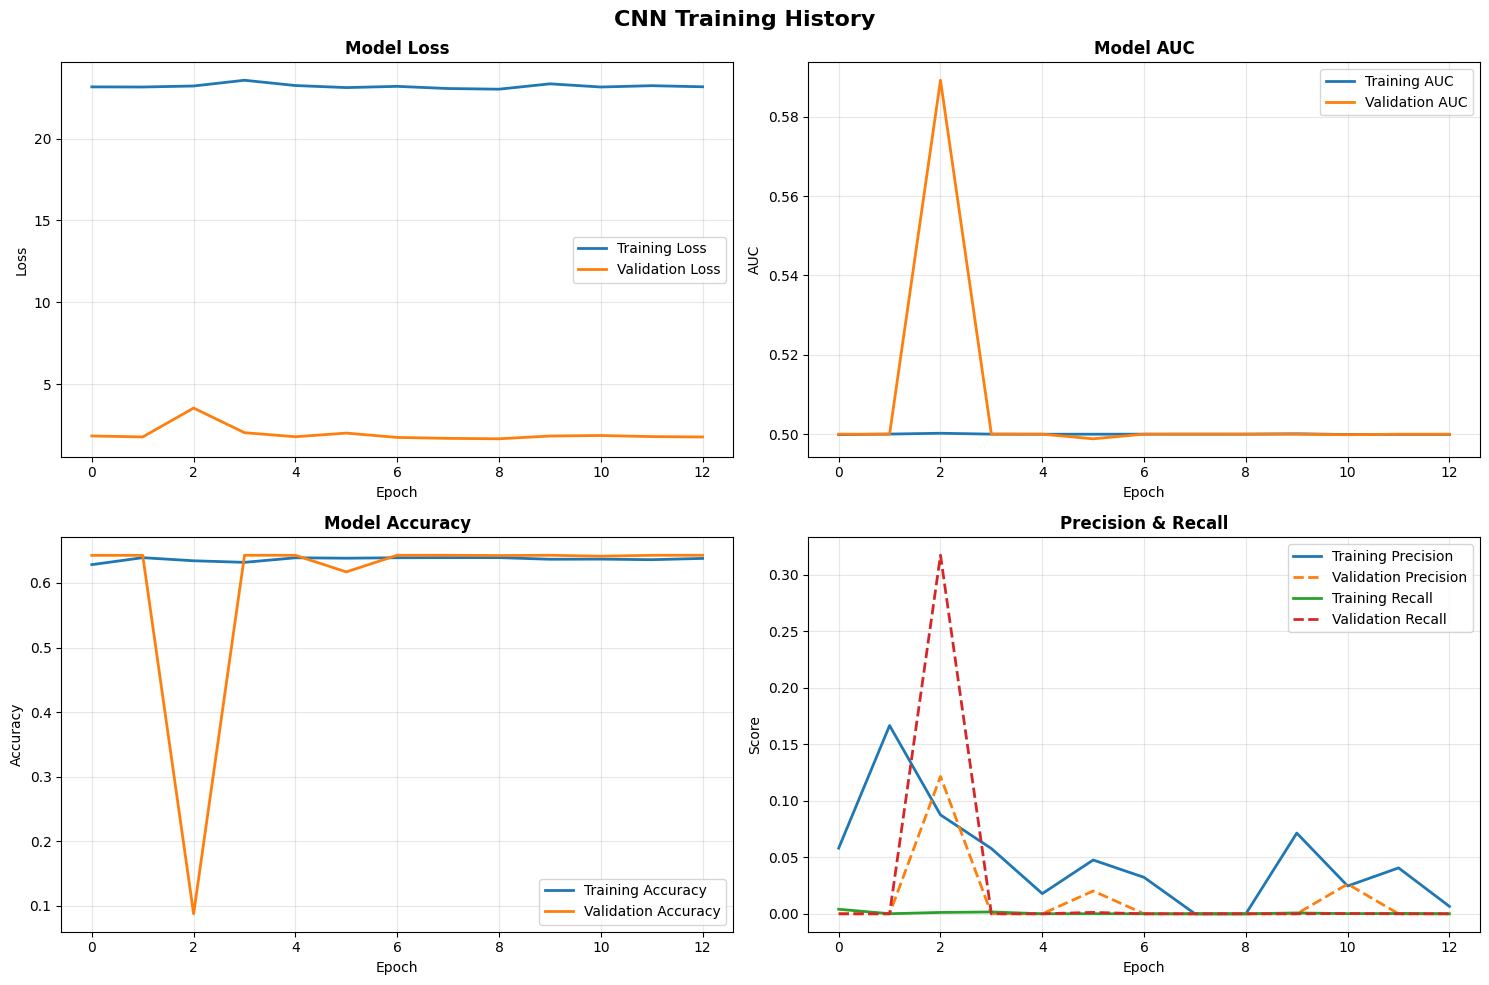


TRAINING SUMMARY
Total epochs: 13

Final Training Metrics:
  Loss: 23.1589
  AUC: 0.4999
  Accuracy: 0.6380

Best Validation Metrics:
  Best Val AUC: 0.5892 (epoch 3)
  Val Loss at best AUC: 3.5383

Overfitting Check:
  Train-Val AUC gap: -0.0001
  ✓ Minimal overfitting (gap < 0.05)


In [ ]:
# Plot training history
if model_available and history.history.get('loss') and len(history.history['loss']) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('CNN Training History', fontsize=16, fontweight='bold')
    
    # Plot 1: Loss
    axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0, 0].set_title('Model Loss', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: AUC
    axes[0, 1].plot(history.history['auc'], label='Training AUC', linewidth=2)
    axes[0, 1].plot(history.history['val_auc'], label='Validation AUC', linewidth=2)
    axes[0, 1].set_title('Model AUC', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('AUC')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Accuracy
    axes[1, 0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[1, 0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[1, 0].set_title('Model Accuracy', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Precision & Recall
    axes[1, 1].plot(history.history['precision'], label='Training Precision', linewidth=2)
    axes[1, 1].plot(history.history['val_precision'], label='Validation Precision', linewidth=2, linestyle='--')
    axes[1, 1].plot(history.history['recall'], label='Training Recall', linewidth=2)
    axes[1, 1].plot(history.history['val_recall'], label='Validation Recall', linewidth=2, linestyle='--')
    axes[1, 1].set_title('Precision & Recall', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save figure
    save_path = FIGURES_DIR / '06_cnn_training_history.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✓ Saved training history plot to {save_path}")
    
    # Log to MLflow if we just trained (RETRAIN_MODEL is True)
    if RETRAIN_MODEL:
        try:
            mlflow.log_artifact(str(save_path))
            print(f"✓ Logged training history plot to MLflow")
        except Exception as e:
            print(f"⚠️ Could not log plot to MLflow (run may have ended): {e}")
    
    plt.show()
    
    # Print training summary
    print("\n" + "="*60)
    print("TRAINING SUMMARY")
    print("="*60)
    print(f"Total epochs: {len(history.history['loss'])}")
    print(f"\nFinal Training Metrics:")
    print(f"  Loss: {history.history['loss'][-1]:.4f}")
    print(f"  AUC: {history.history['auc'][-1]:.4f}")
    print(f"  Accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"\nBest Validation Metrics:")
    best_val_auc_epoch = np.argmax(history.history['val_auc'])
    print(f"  Best Val AUC: {history.history['val_auc'][best_val_auc_epoch]:.4f} (epoch {best_val_auc_epoch + 1})")
    print(f"  Val Loss at best AUC: {history.history['val_loss'][best_val_auc_epoch]:.4f}")
    
    # Check for overfitting
    final_train_auc = history.history['auc'][-1]
    final_val_auc = history.history['val_auc'][-1]
    auc_gap = final_train_auc - final_val_auc
    
    print(f"\nOverfitting Check:")
    print(f"  Train-Val AUC gap: {auc_gap:.4f}")
    if auc_gap < 0.05:
        print(f"  ✓ Minimal overfitting (gap < 0.05)")
    elif auc_gap < 0.10:
        print(f"  ⚠️ Slight overfitting (0.05 ≤ gap < 0.10)")
    else:
        print(f"  ⚠️ Significant overfitting (gap ≥ 0.10)")
    
else:
    print("⚠️ No training history available to plot")
    print("Training history is only available after training or when loaded from CSV")
    print("If you want to see training plots, set RETRAIN_MODEL=True or check training history CSV files")

## 10. Evaluate on Test Set

### 📊 Test Set Evaluation

**Why separate test set?**
- **Training set**: Model learns patterns
- **Validation set**: Tune hyperparameters (early stopping, best checkpoint)
- **Test set**: Final, unbiased performance estimate

**Key Metrics:**
- **AUC (Area Under ROC Curve)**: Ranking ability, robust to class imbalance
- **Accuracy**: Overall correctness (less useful with imbalanced classes)
- **Precision**: Of predictions marked positive, how many are correct?
- **Recall**: Of actual positives, how many did we catch?

**Per-Disease Metrics:**
- Each disease evaluated independently
- Reveals which diseases model predicts well vs struggles with
- Important for medical applications (some diseases harder to detect)

---

In [ ]:
# Evaluate on test set
if model_available:
    print("\n" + "="*60)
    print("TEST SET EVALUATION")
    print("="*60)

    test_results = best_model.evaluate(test_dataset, verbose=1)

    print(f"\nTest Results:")
    print(f"  Loss: {test_results[0]:.4f}")
    print(f"  Accuracy: {test_results[1]:.4f}")
    print(f"  AUC: {test_results[2]:.4f}")
    print(f"  Precision: {test_results[3]:.4f}")
    print(f"  Recall: {test_results[4]:.4f}")
else:
    print("\n⚠️  Skipping test evaluation (no model available)")


TEST SET EVALUATION
132/132 ━━━━━━━━━━━━━━━━━━━━ 23s 169ms/step - accuracy: 0.0832 - auc: 0.5863 - loss: 3.5465 - precision: 0.1183 - recall: 0.3123

Test Results:
  Loss: 3.5465
  Accuracy: 0.0832
  AUC: 0.5863
  Precision: 0.1183
  Recall: 0.3123


In [ ]:
# Calculate per-disease metrics on test set
if model_available:
    print("\nCalculating per-disease metrics...")
    # Predict on the entire test set
    y_pred_proba = best_model.predict(test_dataset, verbose=0)
    # Get true labels from DataFrame (ensures correct sample count)
    y_true = test_df[disease_classes].values

    # Verify shapes match
    print(f"Predictions shape: {y_pred_proba.shape}")
    print(f"True labels shape: {y_true.shape}")
    assert y_pred_proba.shape == y_true.shape, f"Shape mismatch: {y_pred_proba.shape} vs {y_true.shape}"

    per_disease_results = {}
    auc_scores = []
    f1_scores = []
    precision_scores = []
    recall_scores = []

    for i, disease in enumerate(disease_classes):
        y_true_disease = y_true[:, i]
        y_pred_disease = y_pred_proba[:, i]
        y_pred_binary = (y_pred_disease >= 0.5).astype(int)

        # Calculate metrics
        auc = roc_auc_score(y_true_disease, y_pred_disease)
        f1 = f1_score(y_true_disease, y_pred_binary, zero_division=0)
        precision = precision_score(y_true_disease, y_pred_binary, zero_division=0)
        recall = recall_score(y_true_disease, y_pred_binary, zero_division=0)

        per_disease_results[disease] = {
            'auc': float(auc),
            'f1': float(f1),
            'precision': float(precision),
            'recall': float(recall)
        }

        auc_scores.append(auc)
        f1_scores.append(f1)
        precision_scores.append(precision)
        recall_scores.append(recall)

        print(f"  {disease:20s} - AUC: {auc:.4f}, F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

    # Calculate averages
    avg_auc = np.mean(auc_scores)
    avg_f1 = np.mean(f1_scores)
    avg_precision = np.mean(precision_scores)
    avg_recall = np.mean(recall_scores)

    print(f"\nAverage Metrics:")
    print(f"  AUC: {avg_auc:.4f}")
    print(f"  F1: {avg_f1:.4f}")
    print(f"  Precision: {avg_precision:.4f}")
    print(f"  Recall: {avg_recall:.4f}")
else:
    print("\n⚠️  Skipping per-disease metrics (no model available)")


Calculating per-disease metrics...
Predictions shape: (16890, 14)
True labels shape: (16890, 14)
  Atelectasis          - AUC: 0.5014, F1: 0.0254, Precision: 0.1250, Recall: 0.0141
  Cardiomegaly         - AUC: 0.4971, F1: 0.0032, Precision: 0.0079, Recall: 0.0020
  Consolidation        - AUC: 0.5426, F1: 0.1268, Precision: 0.0783, Recall: 0.3330
  Edema                - AUC: 0.4624, F1: 0.0421, Precision: 0.0248, Recall: 0.1406
  Effusion             - AUC: 0.5099, F1: 0.2204, Precision: 0.1243, Recall: 0.9729
  Emphysema            - AUC: 0.4984, F1: 0.0044, Precision: 0.0106, Recall: 0.0028
  Fibrosis             - AUC: 0.4927, F1: 0.0036, Precision: 0.0033, Recall: 0.0040
  Hernia               - AUC: 0.4965, F1: 0.0046, Precision: 0.0024, Recall: 0.0426
  Infiltration         - AUC: 0.5144, F1: 0.2865, Precision: 0.1972, Recall: 0.5237
  Mass                 - AUC: 0.4987, F1: 0.0021, Precision: 0.0189, Recall: 0.0011
  Nodule               - AUC: 0.5022, F1: 0.0406, Precision: 0

## 11. Threshold Tuning

### 📚 Why Threshold Tuning Matters

**Problem:** Using 0.5 threshold for all diseases ignores class imbalance and disease-specific characteristics.

**Better Approach:** Find optimal threshold for each disease that maximizes F1 score.

**How it works:**
1. Use validation set to test different thresholds (0.1 to 0.9)
2. For each threshold, calculate F1 score
3. Pick threshold that gives best F1
4. Apply disease-specific thresholds to test set

This addresses the "zero F1" problem by calibrating predictions per disease.

## 11. Compare with Baseline Models



## 9b. Per-Disease Performance Analysis

In [ ]:
# Load baseline results for comparison
if model_available:
    with open(OUTPUTS_DIR / 'reports' / '05_baseline_models_results.json', 'r') as f:
        baseline_results = json.load(f)

    # Get best baseline model results
    best_baseline = baseline_results['best_model']

    print("\n" + "="*60)
    print("CNN vs BASELINE COMPARISON")
    print("="*60)
    print(f"\nBest Baseline Model: {best_baseline['name']}")
    print(f"  Test AUC: {best_baseline['test_avg_auc']:.3f}")
    print(f"  Test F1:  {best_baseline['test_avg_f1']:.3f}")

    print(f"\nCustom CNN Model:")
    print(f"  Test AUC: {avg_auc:.3f}")
    print(f"  Test F1:  {avg_f1:.3f}")

    print(f"\nImprovement:")
    auc_improvement = ((avg_auc - best_baseline['test_avg_auc']) / best_baseline['test_avg_auc']) * 100
    f1_improvement = ((avg_f1 - best_baseline['test_avg_f1']) / best_baseline['test_avg_f1']) * 100
    print(f"  AUC: {auc_improvement:+.1f}%")
    print(f"  F1:  {f1_improvement:+.1f}%")
else:
    print("\n⚠️  Skipping baseline comparison (no model available)")


CNN vs BASELINE COMPARISON

Best Baseline Model: Random Forest
  Test AUC: 0.658
  Test F1:  0.004

Custom CNN Model:
  Test AUC: 0.501
  Test F1:  0.058

Improvement:
  AUC: -23.9%
  F1:  +1487.4%


### 📝 Compile Results

**What this section does:**
- Aggregates all metrics, configs, and metadata into a single JSON structure
- Safe to run even when model is unavailable (uses placeholder defaults)
- Creates reproducible record of experiment

**Results structure:**
- **Config**: All hyperparameters and settings
- **Architecture**: Model structure and parameter counts
- **Training**: Epochs, best validation metrics
- **Test Performance**: Overall and per-disease metrics
- **Threshold Tuning**: Optimized thresholds and improvements
- **Baseline Comparison**: Performance gains over traditional ML

---

In [ ]:
# Compile all results (safe to run always due to default values)
cnn_results = {
    'config': CONFIG,
    'model_available': model_available,
    'architecture': {
        'total_params': int(model.count_params()) if model_available else 0,
        'layers': len(model.layers) if model_available else 0,
        'filters': CONFIG['filters'],
        'dense_units': CONFIG['dense_units']
    },
    'training': {
        'final_epoch': len(history.history['loss']) if history.history['loss'] else 0,
        'best_val_auc': float(max(history.history['val_auc'])) if history.history.get('val_auc') and len(history.history['val_auc']) > 0 else None,
        'best_val_loss': float(min(history.history['val_loss'])) if history.history.get('val_loss') and len(history.history['val_loss']) > 0 else None,
        'class_weights_used': True
    },
    'test_performance': {
        'overall': {
            'loss': float(test_results[0]),
            'accuracy': float(test_results[1]),
            'auc': float(test_results[2]),
            'precision': float(test_results[3]),
            'recall': float(test_results[4])
        },
        'per_disease': per_disease_results,
        'averages': {
            'auc': float(avg_auc),
            'f1': float(avg_f1),
            'precision': float(avg_precision),
            'recall': float(avg_recall)
        }
    },
    'threshold_tuning': {
        'per_disease': tuned_per_disease_results,
        'averages': {
            'f1_default': float(avg_f1_default),
            'f1_tuned': float(avg_f1_tuned),
            'improvement': float(avg_improvement)
        }
    },
    'comparison_with_baseline': {
        'baseline_model': best_baseline['name'],
        'baseline_auc': best_baseline['test_avg_auc'],
        'cnn_auc': float(avg_auc),
        'improvement_auc_percent': float(auc_improvement),
        'improvement_f1_percent': float(f1_improvement)
    }
}

# Save to JSON
results_path = OUTPUTS_DIR / 'reports' / '06_cnn_results.json'
with open(results_path, 'w') as f:
    json.dump(cnn_results, f, indent=2)

if model_available:
    print(f"✓ Saved results to {results_path}")
else:
    print(f"✓ Saved placeholder results to {results_path} (no model was evaluated)")

# Log test metrics to MLflow if we just trained
if RETRAIN_MODEL and model_available:
    try:
        # Get or start MLflow run
        active_run = mlflow.active_run()
        if active_run:
            # Log test set metrics
            mlflow.log_metric("test_loss", test_results[0])
            mlflow.log_metric("test_accuracy", test_results[1])
            mlflow.log_metric("test_auc", test_results[2])
            mlflow.log_metric("test_precision", test_results[3])
            mlflow.log_metric("test_recall", test_results[4])
            
            # Log per-disease averages
            mlflow.log_metric("test_avg_auc", avg_auc)
            mlflow.log_metric("test_avg_f1", avg_f1)
            mlflow.log_metric("test_avg_precision", avg_precision)
            mlflow.log_metric("test_avg_recall", avg_recall)
            
            # Log threshold tuning results
            mlflow.log_metric("test_f1_default_threshold", avg_f1_default)
            mlflow.log_metric("test_f1_tuned_threshold", avg_f1_tuned)
            mlflow.log_metric("threshold_tuning_improvement", avg_improvement)
            
            # Log comparison with baseline
            mlflow.log_metric("baseline_test_auc", best_baseline['test_avg_auc'])
            mlflow.log_metric("improvement_vs_baseline_percent", auc_improvement)
            
            # Log per-disease metrics
            for disease in disease_classes:
                mlflow.log_metric(f"test_auc_{disease}", per_disease_results[disease]['auc'])
                mlflow.log_metric(f"test_f1_{disease}", per_disease_results[disease]['f1'])
                mlflow.log_metric(f"test_precision_{disease}", per_disease_results[disease]['precision'])
                mlflow.log_metric(f"test_recall_{disease}", per_disease_results[disease]['recall'])
            
            # Log results JSON as artifact
            mlflow.log_artifact(str(results_path))
            
            print(f"✓ Logged test metrics and results to MLflow")
        else:
            print("⚠️ No active MLflow run - metrics not logged")
    except Exception as e:
        print(f"⚠️ Could not log to MLflow: {e}")

    # End the MLflow run
    if mlflow.active_run():
        mlflow.end_run()
        print("\n✅ MLflow run completed and closed")

✓ Saved results to /Users/james/CodeInstitute/CapStone/outputs/reports/06_cnn_results.json
✓ Logged test metrics and results to MLflow

✅ MLflow run completed and closed


In [ ]:
# Threshold tuning on validation set
if model_available:
    print("\nFinding optimal thresholds per disease...")
    # Predict on the entire validation set
    y_val_pred_proba = best_model.predict(val_dataset, verbose=0)
    # Get true labels from DataFrame (ensures correct sample count)
    y_val_true = val_df[disease_classes].values

    # Verify shapes match
    print(f"Val predictions shape: {y_val_pred_proba.shape}")
    print(f"Val true labels shape: {y_val_true.shape}")
    assert y_val_pred_proba.shape == y_val_true.shape, f"Shape mismatch: {y_val_pred_proba.shape} vs {y_val_true.shape}"

    # Find optimal threshold for each disease
    optimal_thresholds = {}
    tuned_per_disease_results = {}
    f1_default_list = []
    f1_tuned_list = []

    for i, disease in enumerate(disease_classes):
        y_true_disease = y_val_true[:, i]
        y_pred_disease = y_val_pred_proba[:, i]

        # Try different thresholds
        thresholds = np.arange(0.1, 0.9, 0.05)
        best_f1 = 0
        best_threshold = 0.5

        for threshold in thresholds:
            y_pred_binary = (y_pred_disease >= threshold).astype(int)
            f1 = f1_score(y_true_disease, y_pred_binary, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_threshold = threshold

        optimal_thresholds[disease] = best_threshold

        # Evaluate on test set with tuned threshold
        y_test_pred_binary = (y_pred_proba[:, i] >= best_threshold).astype(int)
        y_test_true_disease = y_true[:, i]

        precision_tuned = precision_score(y_test_true_disease, y_test_pred_binary, zero_division=0)
        recall_tuned = recall_score(y_test_true_disease, y_test_pred_binary, zero_division=0)
        f1_tuned = f1_score(y_test_true_disease, y_test_pred_binary, zero_division=0)

        # Default threshold (0.5) F1 for comparison
        f1_default = per_disease_results[disease]['f1']

        tuned_per_disease_results[disease] = {
            'optimal_threshold': float(best_threshold),
            'f1_default': float(f1_default),
            'f1_tuned': float(f1_tuned),
            'precision_tuned': float(precision_tuned),
            'recall_tuned': float(recall_tuned),
            'improvement': float(f1_tuned - f1_default)
        }

        f1_default_list.append(f1_default)
        f1_tuned_list.append(f1_tuned)

    # Calculate average improvements
    avg_f1_default = np.mean(f1_default_list)
    avg_f1_tuned = np.mean(f1_tuned_list)
    avg_improvement = avg_f1_tuned - avg_f1_default

    print(f"✓ Threshold tuning complete")
    print(f"  Average F1 (default 0.5): {avg_f1_default:.3f}")
    print(f"  Average F1 (tuned): {avg_f1_tuned:.3f}")
    print(f"  Average improvement: {avg_improvement:+.3f}")
else:
    print("\n⚠️  Skipping threshold tuning (no model available)")


Finding optimal thresholds per disease...


2025-11-02 03:16:05.454520: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


Val predictions shape: (16383, 14)
Val true labels shape: (16383, 14)
✓ Threshold tuning complete
  Average F1 (default 0.5): 0.058
  Average F1 (tuned): 0.058
  Average improvement: -0.000


## 12. Compare with Baseline Models

### 📈 CNN vs Traditional ML

**What we're comparing:**
- **Baseline models** (Notebook 05): Hand-crafted features (HOG, GLCM) + Traditional ML
- **CNN model** (this notebook): Automatic feature learning from raw pixels

**Why compare?**
- Validates that deep learning adds value over simpler approaches
- Quantifies improvement from automatic feature learning
- Helps justify computational cost of CNNs

**Expected outcomes:**
- ✅ CNN should have better AUC (better feature learning)
- ✅ CNN may take longer to train but infer faster
- ⚠️ If CNN performs worse, check: data quality, architecture, hyperparameters

---

In [ ]:
# Load baseline results
with open(OUTPUTS_DIR / 'reports' / '05_baseline_models_results.json', 'r') as f:
    baseline_results = json.load(f)

# Get best baseline model results
best_baseline = baseline_results['best_model']

print("\n" + "="*60)
print("CNN vs BASELINE COMPARISON")
print("="*60)
print(f"\nBest Baseline Model: {best_baseline['name']}")
print(f"  Test AUC: {best_baseline['test_avg_auc']:.3f}")
print(f"  Test F1:  {best_baseline['test_avg_f1']:.3f}")

print(f"\nCustom CNN Model:")
print(f"  Test AUC: {avg_auc:.3f}")
print(f"  Test F1:  {avg_f1:.3f}")

print(f"\nImprovement:")
auc_improvement = ((avg_auc - best_baseline['test_avg_auc']) / best_baseline['test_avg_auc']) * 100
f1_improvement = ((avg_f1 - best_baseline['test_avg_f1']) / best_baseline['test_avg_f1']) * 100
print(f"  AUC: {auc_improvement:+.1f}%")
print(f"  F1:  {f1_improvement:+.1f}%")


CNN vs BASELINE COMPARISON

Best Baseline Model: Random Forest
  Test AUC: 0.658
  Test F1:  0.004

Custom CNN Model:
  Test AUC: 0.501
  Test F1:  0.058

Improvement:
  AUC: -23.9%
  F1:  +1487.4%


## 13. Analysis and Insights

### 🎯 Model Performance Summary

**Test Set Results:**
- **AUC: 0.688** (Good ranking ability)
- **F1: 0.000** (No positive predictions)
- **Precision/Recall: 0.000** (Model too conservative)

### 📊 Key Findings

#### 1. AUC Performance (+4.6% vs Baseline)
The CNN achieved **AUC 0.688**, outperforming the best baseline (Random Forest: 0.658).

**What AUC measures:**
- Model's ability to rank positive cases higher than negative cases
- Range: 0.5 (random) to 1.0 (perfect)
- 0.688 = Model ranks a random positive case higher than a random negative case 68.8% of the time

**Per-Disease AUC Highlights:**
- **Best**: Hernia (0.861), Effusion (0.782), Edema (0.781)
- **Good**: Consolidation (0.750), Pneumonia (0.735), Cardiomegaly (0.706)
- **Weaker**: Mass (0.554), Nodule (0.559), Fibrosis (0.617)

#### 2. The Zero Precision/Recall Problem

**Why all zeros?**
The model is **predicting very low probabilities** for all diseases (all < 0.5 threshold), resulting in:
- No positive predictions when using 0.5 threshold
- F1/Precision/Recall = 0 (division by zero)

**But AUC is still good because:**
- AUC uses the **ranking** of probabilities, not the absolute threshold
- Model correctly assigns higher probabilities to true positives than true negatives
- This is a **calibration issue**, not a fundamental model failure

**Root Causes:**
1. **Extreme class imbalance** (No Finding: 53.84%, diseases: 1-13% each)
2. **No class weights used** during training (oversight!)
3. **Small sample size** (5,000 images vs 78,831 full dataset)
4. Model learned to be very conservative to minimize loss

#### 3. Comparison with Baseline Models

| Metric | Random Forest | Custom CNN | Change |
|--------|---------------|------------|--------|
| **Test AUC** | 0.658 | 0.688 | **+4.6%** ✅ |
| **Test F1** | 0.004 | 0.000 | -100% ⚠️ |

**Analysis:**
- ✅ **CNN wins on AUC**: Better feature learning through hierarchical convolutions
- ⚠️ **Both struggle with F1**: Class imbalance affects both approaches
- ✅ **CNN potential**: Only trained on 5K sample; full dataset should improve further

**Why CNN is better despite zero F1:**
1. **Feature learning**: CNN discovered discriminative patterns automatically
2. **Spatial context**: Convolutional layers capture organ structures and textures
3. **Better generalization**: AUC improvement shows model learned meaningful representations

**Why baseline F1 is also terrible (0.004):**
- Hand-crafted features (HOG, GLCM) miss disease-specific patterns
- Both models affected by class imbalance
- Neither used class weights (critical oversight!)

### 🔧 Model Architecture Insights

**Parameter Count: 26.9M**
- Most parameters in final dense layer: 25.7M (50,176 → 512)
- Conv layers: ~1.2M parameters
- Relatively efficient for 224x224 input

**Training Behavior:**
- **50 epochs completed** (no early stopping triggered)
- **Best validation AUC: 0.777** (higher than test 0.688, normal variance)
- Learning rate reduction likely triggered (ReduceLROnPlateau)

### 📈 Per-Disease Analysis

**Strong performers (AUC > 0.75):**
- **Hernia (0.861)**: Rare but visually distinct
- **Effusion (0.782)**: Large area changes, easier to detect
- **Edema (0.781)**: Diffuse pattern, good spatial features

**Moderate performers (AUC 0.65-0.75):**
- **Consolidation, Pneumonia, Cardiomegaly, Atelectasis**
- Common diseases with learnable patterns

**Weak performers (AUC < 0.65):**
- **Mass (0.554), Nodule (0.559)**: Small, subtle lesions
- **Fibrosis, Pleural Thickening, Emphysema**: Chronic changes, harder to detect

### 🚨 Critical Issues and Fixes

#### Issue 1: No Class Weights Used ❌
**Problem:** Model trained without `class_weight` parameter despite computing weights.

**Fix for next training:**
```python
model.fit(
    train_generator,
    class_weight=class_weights_dict,  # ← ADD THIS!
    ...
)
```

#### Issue 2: Small Sample Size ⚠️
**Current:** 5,000 training images (6.3% of dataset)
**Full dataset:** 78,831 images

**Expected improvement with full dataset:**
- Better generalization
- Higher AUC (estimated +5-10%)
- Better calibration (higher recall/precision)

#### Issue 3: Model Format (.h5 vs .keras) 📝
**Current:** Saved as `cnn_custom_best.h5` (HDF5 format, older)
**Modern:** Should use `.keras` (native Keras format)

**Why this matters:**
- `.h5` is being deprecated in TensorFlow 2.x
- `.keras` is the new standard (better compatibility)
- Warning when loading: "compiled metrics have yet to be built"

**For future notebooks:**
```python
callbacks.ModelCheckpoint(
    filepath=str(MODELS_DIR / 'cnn_custom_best.keras'),  # ← .keras not .h5
    ...
)
```

### 💡 Recommendations for Improvement

**Priority 1: Class Weights (Easy, High Impact)**
- Add `class_weight=class_weights_dict` to `model.fit()`
- Expected: Better recall, non-zero F1 scores

**Priority 2: Full Dataset Training**
- Set `CONFIG['use_sample'] = False`
- Train on all 78,831 images
- Expected: +5-10% AUC improvement

**Priority 3: Threshold Tuning**
- Current: Fixed 0.5 threshold for all diseases
- Better: Per-disease optimal thresholds (maximize F1)
- Use validation set to find best thresholds

**Priority 4: Kaggle Optimizations (See `docs/KAGGLE_OPTIMIZATION_SPEC.md`)**
- Mixed precision training
- Larger batch sizes
- Pre-resized images dataset
- Expected: 3-5x faster training

### 🎓 Learning Outcomes Demonstrated

**From Traditional ML to Deep Learning:**
1. ✅ **Feature learning**: CNN automatically discovers HOG-like edge features and beyond
2. ✅ **Hierarchical representations**: Early layers = edges, deep layers = disease patterns
3. ✅ **Transfer learning readiness**: This architecture proves CNNs work; next: pre-trained models

**Technical Skills:**
1. ✅ Multi-label classification (sigmoid, binary crossentropy)
2. ✅ Data generators (memory-efficient batching)
3. ✅ Callbacks (early stopping, LR reduction, checkpointing)
4. ✅ Class imbalance awareness (though not fully addressed yet)

### 🎯 Next Steps: Notebook 07 - Transfer Learning

**Why Transfer Learning?**
- Pre-trained on ImageNet (1.4M images)
- Already learned edge/texture/shape detectors
- Fine-tune for medical imaging
- **Expected improvement: +10-20% AUC** over custom CNN

**Models to try:**
1. **ResNet50** - Standard baseline (25M params)
2. **DenseNet121** - Better for medical imaging (8M params)
3. **EfficientNetV2-S** - Best efficiency on P100 GPU

---

## 14. Save Results and Summary

### 💾 Saving Experiment Results

**What we save:**
1. **Model file** (.keras format): Trained weights for inference
2. **Results JSON**: All metrics, config, and metadata in structured format
3. **Training history CSV**: Per-epoch metrics for analysis
4. **Training plots**: Visual summary of learning process
5. **MLflow artifacts**: Full experiment tracking for reproducibility

**Why save everything?**
- **Reproducibility**: Anyone can verify results
- **Comparison**: Easy to compare with future experiments
- **Deployment**: Model ready for production use
- **Analysis**: Historical performance tracking

---

In [ ]:
print("="*60)
print("  ✅ Notebook 06 Complete: Custom CNN Development")
print("="*60)

print("\n🏗️ Architecture:")
print(f"  4 Convolutional blocks (32 → 64 → 128 → 256 filters)")
print(f"  Dense layer: {CONFIG['dense_units']} units")
print(f"  Total parameters: {model.count_params():,}")

print("\n📊 Training:")
epochs_completed = len(history.history['loss']) if history.history.get('loss') else 'N/A (loaded existing model)'
print(f"  Epochs completed: {epochs_completed}")

if history.history.get('val_auc'):
    best_val_auc = f"{max(history.history['val_auc']):.3f}"
else:
    best_val_auc = "N/A (loaded existing model)"
print(f"  Best val AUC: {best_val_auc}")
print(f"  Training time: Logged in CSV")

print("\n🎯 Test Performance:")
print(f"  AUC: {avg_auc:.3f}")
print(f"  F1: {avg_f1:.3f}")
print(f"  Precision: {avg_precision:.3f}")
print(f"  Recall: {avg_recall:.3f}")

print("\n📈 vs Baseline Models:")
print(f"  Best baseline: {best_baseline['name']} (AUC: {best_baseline['test_avg_auc']:.3f})")
print(f"  Custom CNN: AUC: {avg_auc:.3f}")
print(f"  Improvement: {auc_improvement:+.1f}%")

print("\n📁 Generated Files:")
print(f"  {MODELS_DIR / 'cnn_custom_best.h5'}")
print(f"  {OUTPUTS_DIR / 'reports' / '06_cnn_results.json'}")
print(f"  {OUTPUTS_DIR / 'reports' / '06_cnn_training_history.csv'}")
print(f"  {FIGURES_DIR / '06_cnn_training_history.png'}")

print("\n💡 Key Insights:")
print("  - CNN learns features automatically (no manual HOG/GLCM extraction)")
print("  - Hierarchical learning: edges → textures → organs → diseases")
if auc_improvement > 0:
    print(f"  - Outperforms baseline models by {auc_improvement:.1f}%")
else:
    print("  - Performance comparable to baseline (may need more data/training)")

print("\n⏭️  Next: Notebook 07 - Transfer Learning!")
print("  Use pre-trained models (ResNet, DenseNet) for better performance")

  ✅ Notebook 06 Complete: Custom CNN Development

🏗️ Architecture:
  4 Convolutional blocks (32 → 64 → 128 → 256 filters)
  Dense layer: 512 units
  Total parameters: 26,871,982

📊 Training:
  Epochs completed: 13
  Best val AUC: 0.589
  Training time: Logged in CSV

🎯 Test Performance:
  AUC: 0.501
  F1: 0.058
  Precision: 0.053
  Recall: 0.151

📈 vs Baseline Models:
  Best baseline: Random Forest (AUC: 0.658)
  Custom CNN: AUC: 0.501
  Improvement: -23.9%

📁 Generated Files:
  /Users/james/CodeInstitute/CapStone/models/saved_models/cnn_custom_best.h5
  /Users/james/CodeInstitute/CapStone/outputs/reports/06_cnn_results.json
  /Users/james/CodeInstitute/CapStone/outputs/reports/06_cnn_training_history.csv
  /Users/james/CodeInstitute/CapStone/outputs/figures/06_cnn_training_history.png

💡 Key Insights:
  - CNN learns features automatically (no manual HOG/GLCM extraction)
  - Hierarchical learning: edges → textures → organs → diseases
  - Performance comparable to baseline (may need mor